# Cycling Patterns in Flanders
**Modern Data Analytics - Group 2 - KU Leuven**

In [5]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

sys.path.insert(0, str(Path.cwd().parent))

from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor

# Global config
RANDOM_STATE = 42
PROCESSED_DIR = Path.cwd().parent / "data" / "processed"
FIG_DIR = Path.cwd().parent / "figures"
FIG_DIR.mkdir(exist_ok=True)

# Plot styling
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Machine Learning Pipeline

In [6]:
df = pd.read_parquet(PROCESSED_DIR / "cycling_with_weather.parquet")
print(f"Hourly data: {len(df):,} rows")

daily = (
    df.groupby([df["timestamp"].dt.normalize().rename("date"), "site_id", "gemeente"])
      .agg(
          count=("count", "sum"),
          temperature_2m=("temperature_2m", "mean"),
          precipitation=("precipitation", "sum"),
          wind_speed_10m=("wind_speed_10m", "mean"),
          cloud_cover=("cloud_cover", "mean"),
      )
      .reset_index()
)

daily["day_of_week"] = daily["date"].dt.dayofweek.astype("int8")
daily["month"] = daily["date"].dt.month.astype("int8")
daily["year"] = daily["date"].dt.year.astype("int16")
daily["is_weekend"] = daily["day_of_week"] >= 5

from src.features import COVID_PERIODS
daily["covid_period"] = "other"
for label, (start, end) in COVID_PERIODS.items():
    mask = daily["date"].between(start, end)
    daily.loc[mask, "covid_period"] = label

import holidays
be_holidays = holidays.country_holidays("BE", years=daily["year"].unique())
daily["is_holiday"] = daily["date"].dt.date.map(lambda d: d in be_holidays)

daily = daily.dropna(subset=["temperature_2m"])
daily.to_parquet(PROCESSED_DIR / "daily_for_modeling.parquet", index=False)
print(f"Saved {len(daily):,} daily rows")

Hourly data: 10,419,659 rows
Saved 217,193 daily rows


In [7]:
daily.head()

,date,site_id,gemeente,count,temperature_2m,precipitation,wind_speed_10m,cloud_cover,day_of_week,month,year,is_weekend,covid_period,is_holiday
0,2019-08-01,1,Machelen,495,18.891667,1.8,13.591667,63.916667,3,8,2019,False,pre_covid,False
1,2019-08-01,10,Aalst 2,260,18.891667,1.8,13.591667,63.916667,3,8,2019,False,pre_covid,False
2,2019-08-01,11,Aalst 3,366,18.891667,1.8,13.591667,63.916667,3,8,2019,False,pre_covid,False
3,2019-08-01,12,Tervuren,377,18.891667,1.8,13.591667,63.916667,3,8,2019,False,pre_covid,False
4,2019-08-01,13,Gent,713,18.891667,1.8,13.591667,63.916667,3,8,2019,False,pre_covid,False


In [9]:
from src.modeling import (
    time_aware_split, build_pipeline, fit_with_time_cv, evaluate, ALL_FEATURES,
)

daily = daily.sort_values("date").reset_index(drop=True)

# Cutoff: last 20% of data
cutoff = daily["date"].quantile(0.8).strftime("%Y-%m-%d")
print(f"Cutoff: {cutoff}")

train_df, test_df = time_aware_split(daily, cutoff_date=cutoff)

X_train = train_df[ALL_FEATURES]
y_train = train_df["count"]
X_test = test_df[ALL_FEATURES]
y_test = test_df["count"]

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Cutoff: 2025-06-28
Cutoff: 2025-06-28
Train: 2019-08-01 -> 2025-06-27 (173,628 rows)
Test:  2025-06-28 -> 2026-04-30 (43,565 rows)
Train shape: (173628, 10), Test shape: (43565, 10)


In [10]:
# Ridge baseline
pipe_ridge = build_pipeline(Ridge(random_state=RANDOM_STATE))
grid_ridge = {"regressor__alpha": [0.1, 1.0, 10.0, 100.0]}

best_ridge = fit_with_time_cv(pipe_ridge, X_train, y_train, grid_ridge)
ridge_metrics = evaluate(best_ridge, X_test, y_test)
print(f"\nRidge test metrics: {ridge_metrics}")

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best params: {'regressor__alpha': 10.0}
Best CV MAE: 197.74

Ridge test metrics: {'MAE': 194.7452478816492, 'RMSE': 362.3954235490047, 'R2': 0.766087523274673}


In [17]:
# Random forest
pipe_rf = build_pipeline(RandomForestRegressor(
    random_state=RANDOM_STATE, 
    n_jobs=1
))
grid_rf = {
    "regressor__n_estimators": [100],
    "regressor__max_depth": [15],
    "regressor__min_samples_leaf": [5],
}

best_rf = fit_with_time_cv(pipe_rf, X_train, y_train, grid_rf)
rf_metrics = evaluate(best_rf, X_test, y_test)
print(f"\nRF test metrics: {rf_metrics}")

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best params: {'regressor__max_depth': 15, 'regressor__min_samples_leaf': 5, 'regressor__n_estimators': 100}
Best CV MAE: 250.23

RF test metrics: {'MAE': 244.60574354275485, 'RMSE': 348.2213121340598, 'R2': 0.7840273916226382}


In [21]:
# Gradient Boosting
pipe_gbr = build_pipeline(GradientBoostingRegressor(random_state=RANDOM_STATE))
grid_gbr = {
    "regressor__n_estimators": [100, 300],
    "regressor__max_depth": [3, 5],
    "regressor__learning_rate": [0.05, 0.1],
}

best_gbr = fit_with_time_cv(pipe_gbr, X_train, y_train, grid_gbr)
gbr_metrics = evaluate(best_gbr, X_test, y_test)
print(f"\nGBR test metrics: {gbr_metrics}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best params: {'regressor__learning_rate': 0.1, 'regressor__max_depth': 5, 'regressor__n_estimators': 300}
Best CV MAE: 167.16

GBR test metrics: {'MAE': 153.96197432406746, 'RMSE': 271.23803519134333, 'R2': 0.8689644434455011}


                      MAE    RMSE    R2
Ridge              194.75  362.40  0.77
Random Forest      244.61  348.22  0.78
Gradient Boosting  153.96  271.24  0.87

Best model on test MAE: Gradient Boosting


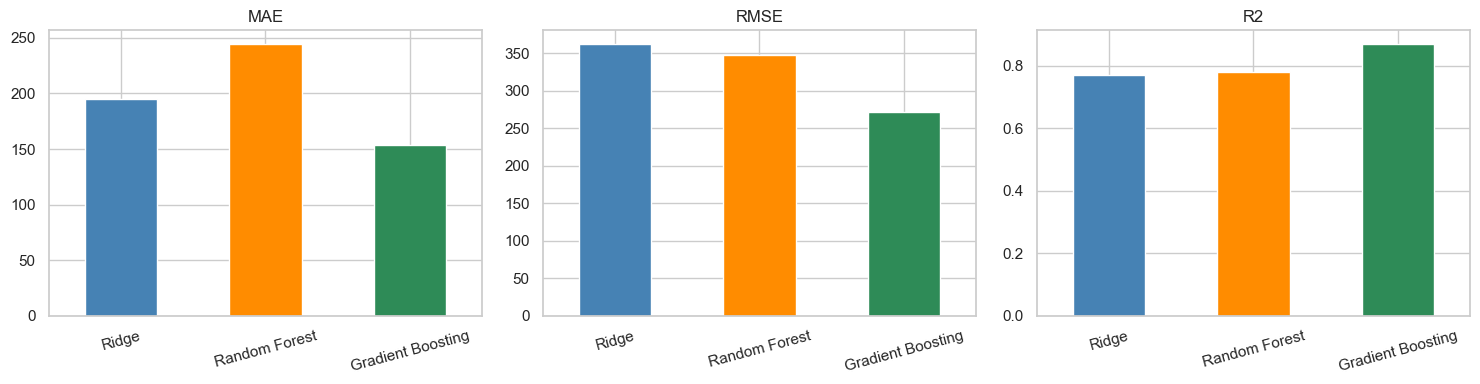

In [22]:
# Compare results
results = pd.DataFrame({
    "Ridge": ridge_metrics,
    "Random Forest": rf_metrics,
    "Gradient Boosting": gbr_metrics,
}).T.round(2)

print(results)

best_model_name = results["MAE"].idxmin()
best_models = {"Ridge": best_ridge, "Random Forest": best_rf, "Gradient Boosting": best_gbr}
best_model = best_models[best_model_name]
print(f"\nBest model on test MAE: {best_model_name}")

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ["MAE", "RMSE", "R2"]):
    results[metric].plot(kind="bar", ax=ax, color=["steelblue", "darkorange", "seagreen"])
    ax.set_title(metric)
    ax.set_xticklabels(results.index, rotation=15)
plt.tight_layout()
plt.savefig(FIG_DIR / "model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

C:\Users\tobia\AppData\Local\Temp\ipykernel_12532\2726545774.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df, y="feature", x="importance", ax=ax, palette="rocket")


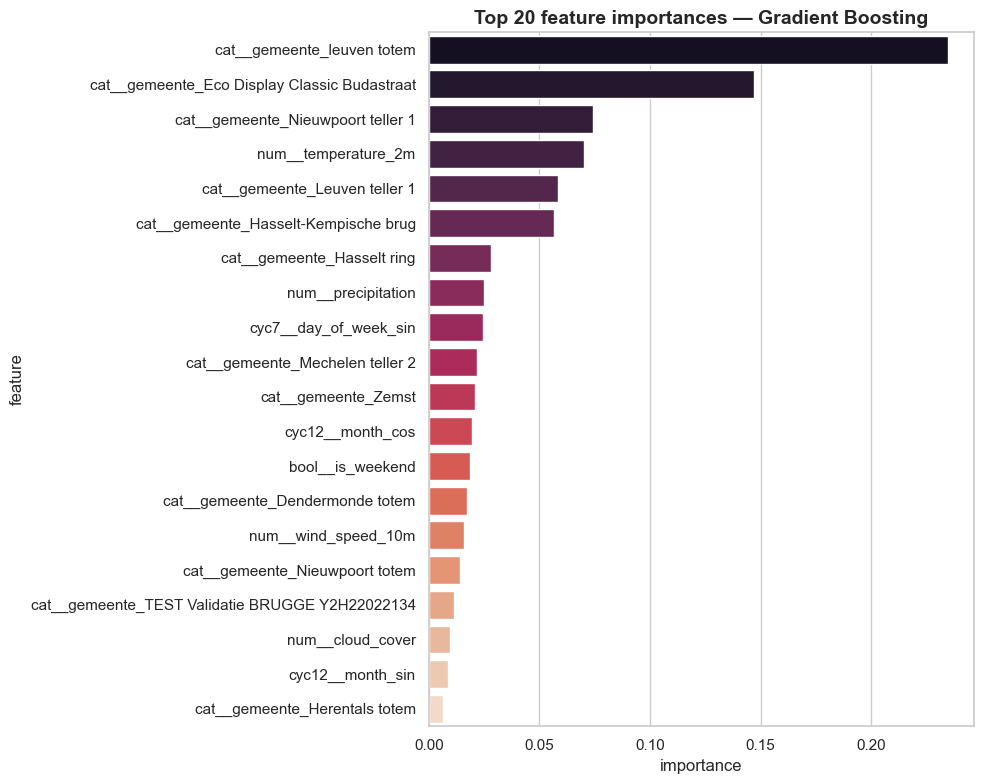

Top 10 features:
                                     feature  importance
                  cat__gemeente_leuven totem    0.234779
cat__gemeente_Eco Display Classic Budastraat    0.146872
           cat__gemeente_Nieuwpoort teller 1    0.074245
                         num__temperature_2m    0.070180
               cat__gemeente_Leuven teller 1    0.058270
        cat__gemeente_Hasselt-Kempische brug    0.056409
                  cat__gemeente_Hasselt ring    0.027912
                          num__precipitation    0.025034
                       cyc7__day_of_week_sin    0.024530
             cat__gemeente_Mechelen teller 2    0.021609


In [23]:
# Feature importance
fitted = best_model.best_estimator_
preprocessor = fitted.named_steps["preprocess"]
regressor = fitted.named_steps["regressor"]

feature_names = preprocessor.get_feature_names_out()

if hasattr(regressor, "feature_importances_"):
    importance = regressor.feature_importances_
    imp_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importance,
    }).sort_values("importance", ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.barplot(data=imp_df, y="feature", x="importance", ax=ax, palette="rocket")
    ax.set_title(f"Top 20 feature importances — {best_model_name}",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("Top 10 features:")
    print(imp_df.head(10).to_string(index=False))
else:
    # Ridge: coefficients
    coefs = pd.DataFrame({
        "feature": feature_names,
        "coefficient": regressor.coef_,
    })
    coefs["abs_coef"] = coefs["coefficient"].abs()
    coefs_top = coefs.sort_values("abs_coef", ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.barplot(data=coefs_top, y="feature", x="coefficient", ax=ax, palette="vlag")
    ax.set_title(f"Top 20 coefficients — {best_model_name}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(coefs_top.to_string(index=False))

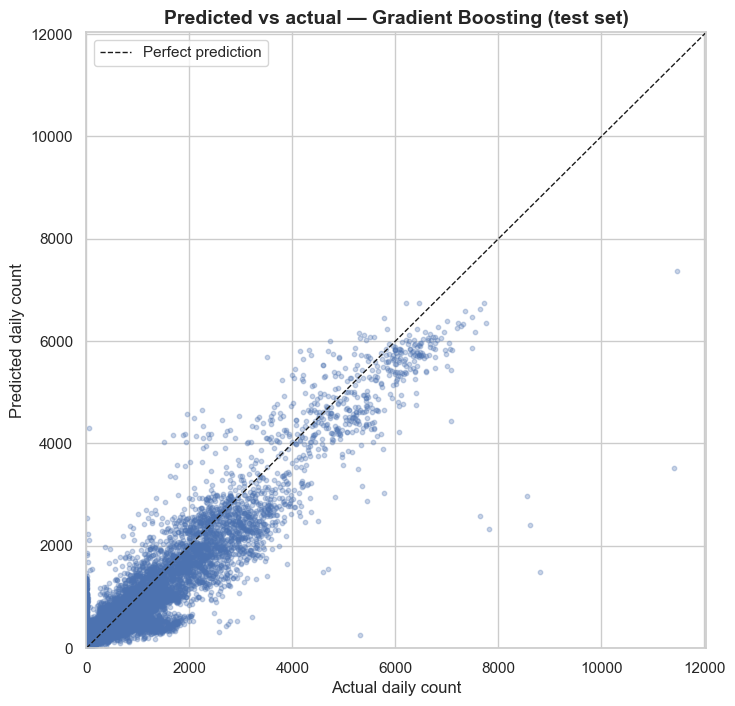

In [24]:
# Predict on test data
y_pred = best_model.predict(X_test)

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, y_pred, alpha=0.3, s=10)
lims = [0, max(y_test.max(), y_pred.max()) * 1.05]
ax.plot(lims, lims, "k--", linewidth=1, label="Perfect prediction")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Actual daily count")
ax.set_ylabel("Predicted daily count")
ax.set_title(f"Predicted vs actual — {best_model_name} (test set)",
             fontsize=14, fontweight="bold")
ax.legend()
plt.savefig(FIG_DIR / "predicted_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()

In [25]:
# Save everything (also in json for dashboard)
model_path = PROCESSED_DIR / "best_model.pkl"
joblib.dump(best_model.best_estimator_, model_path)

import json
metadata = {
    "model_name": best_model_name,
    "best_params": {k: str(v) for k, v in best_model.best_params_.items()},
    "test_metrics": ridge_metrics if best_model_name == "Ridge" else (rf_metrics if best_model_name == "Random Forest" else gbr_metrics),
    "features": ALL_FEATURES,
    "cutoff_date": cutoff,
    "n_train": len(X_train),
    "n_test": len(X_test),
}
with open(PROCESSED_DIR / "model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)